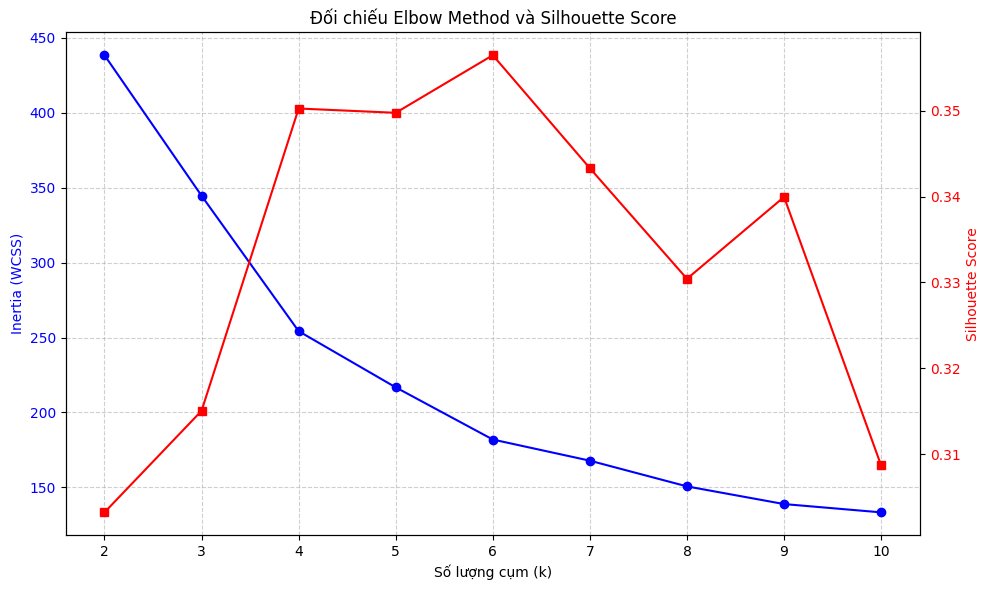

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


df = pd.read_csv('../data/Đã xử lí/scaled_Mall_Customer.csv')


X = df.values 

inertia = []
silhouette_vals = []
k_range = range(2, 11)


for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    
    
    inertia.append(kmeans.inertia_)
    
    
    silhouette_vals.append(silhouette_score(X, cluster_labels))


fig, ax1 = plt.subplots(figsize=(10, 6))


ax1.plot(k_range, inertia, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Số lượng cụm (k)')
ax1.set_ylabel('Inertia (WCSS)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, linestyle='--', alpha=0.6)


ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_vals, 'rs-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Đối chiếu Elbow Method và Silhouette Score')
fig.tight_layout()
plt.show()